# Here the comes the Selective classifiers


In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer

# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score

import pickle

In [2]:
import importlib
import src.utils as utl
importlib.reload(utl)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [3]:
import src.fancy_plots as fplt
importlib.reload(fplt)


<module 'src.fancy_plots' from '/home/vbonsignori/L2loRe/src/fancy_plots.py'>

In [4]:
# let's find the different files we need
config = utl.load_config('config.yaml')
cf_results = config['paths']['counterfactuals']


dt_name = 'adult48k'
dt_name = "toy_dataset"
dt_name = "german_credit"
cf_method = 'ils'#dice or 'debug'
cf_latent = True


name_dataset = {"german_credit": "German Credit", 
                "adult48k": "Adult",
                "toy_dataset":"Toy Dataset",
                }[dt_name]
cf_results

'counterfactuals/'

In [5]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz


In [6]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit/mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [7]:
from selective_classifiers import load_distance_stats,check_res,convert_lists_to_arrays,initialize_rejectors,calibrate_basic_rejectors,calibrate_distance_rejectors,evaluate_rejectors,create_dataframes,visualize_results

## Load the distances files

In [8]:
fname = os.path.join(cf_method,dt_name+"_ranking_latent.pkl")
fname_test = os.path.join(cf_method,dt_name+"_ranking_test_latent.pkl")



# Load distance statistics
all_stats, all_stats_test = load_distance_stats(cf_method, dt_name, cf_latent)



Loaded ils/german_credit_ranking_latent.pkl
Loaded ils/german_credit_ranking_test_latent.pkl


In [9]:
# Check if distances are computed
for k in models.keys():
    print(k, "computed?", check_res(stats_dict=all_stats, k=k))
    print("\t", "test?", check_res(stats_dict=all_stats_test, k=k))

(200 elements computed)
random_forest computed? True
(250 elements computed)
	 test? True
(200 elements computed)
mlp computed? True
(250 elements computed)
	 test? True
(200 elements computed)
xgboost computed? True
(250 elements computed)
	 test? True
(200 elements computed)
lgbm computed? True
(250 elements computed)
	 test? True


In [10]:
all_stats = convert_lists_to_arrays(models, all_stats)
all_stats_test = convert_lists_to_arrays(models, all_stats_test)

#### Here we import the necessary libraries for the 
# Selective classifiers


In [11]:

#from Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss

from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
# use importlib as we have to reload the module
#importlib.reload(cfdr)
import rejectmodels.CFDistRejector as cfdr

from src.utils import compute_selective_metrics



In [12]:
import rejectmodels.CFTreeRejector as cftree
importlib.reload(cftree)

<module 'rejectmodels.CFTreeRejector' from '/home/vbonsignori/L2loRe/rejectmodels/CFTreeRejector.py'>

In [13]:
focus_metrics = ["inf",
 'chebyshev',
 'l2',
 'minkowski',
 'wasserstein',
 'l1',
 'mae',
 'sqeuclidean']
#focus_metrics = ['l2']

In [14]:
rejectors, metric_dicts, info = initialize_rejectors(models, splits)

In [15]:
# Calibrate basic rejectors
rejectors = calibrate_basic_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)

Calibrating basic rejectors:   0%|          | 0/4 [00:00<?, ?it/s]

Calibrating basic rejectors for model random_forest


Calibrating basic rejectors: 100%|██████████| 4/4 [00:00<00:00, 23.41it/s]

Basic rejectors calibrated:
PlugInRule: [16 31 31 20 31]
PlugInRuleAUC: [27. 32. 32.  1. 32.]
Calibrating basic rejectors for model mlp
Basic rejectors calibrated:
PlugInRule: [25 30 23 19 25]
PlugInRuleAUC: [31. 28. 13.  6. 20.]
Calibrating basic rejectors for model xgboost
Basic rejectors calibrated:
PlugInRule: [ 9 30 27  5 31]
PlugInRuleAUC: [22. 30. 23. 11. 32.]
Calibrating basic rejectors for model lgbm
Basic rejectors calibrated:
PlugInRule: [20 30 30 10 32]
PlugInRuleAUC: [29. 30. 29. 10. 32.]


In [16]:
rejectors = calibrate_distance_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)

Calibrating distance-based rejectors:   0%|          | 0/4 [00:00<?, ?it/s]

Calibration done
Tree has score 0.76
Calibration done
Tree has score 0.76
Calibration done
Tree has score 0.865
Calibration done
Tree has score 0.865
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.79
Calibration done
Tree has score 0.79
Calibration done
Tree has score 0.805
Calibration done
Tree has score 0.805
Calibration done
Tree has score 0.815


Calibrating distance-based rejectors:  25%|██▌       | 1/4 [00:00<00:01,  1.93it/s]

Calibration done
Tree has score 0.815
Calibration done
Tree has score 0.84
Calibration done
Tree has score 0.84
Calibration done
Tree has score 0.815
Calibration done
Tree has score 0.815
Calibration done
Tree has score 0.8
Calibration done
Tree has score 0.8
Calibration done
Tree has score 0.84
Calibration done
Tree has score 0.84
Calibration done
Tree has score 0.72


Calibrating distance-based rejectors:  50%|█████     | 2/4 [00:01<00:01,  1.86it/s]

Calibration done
Tree has score 0.72
Calibration done
Tree has score 0.815
Calibration done
Tree has score 0.815
Calibration done
Tree has score 0.82
Calibration done
Tree has score 0.82
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.805


Calibrating distance-based rejectors:  75%|███████▌  | 3/4 [00:01<00:00,  1.98it/s]

Calibration done
Tree has score 0.805
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.835
Calibration done
Tree has score 0.825
Calibration done
Tree has score 0.825
Calibration done
Tree has score 0.815
Calibration done
Tree has score 0.815
Calibration done
Tree has score 0.765
Calibration done
Tree has score 0.765
Calibration done
Tree has score 0.855
Calibration done
Tree has score 0.855
Calibration done
Tree has score 0.77
Calibration done
Tree has score 0.77


Calibrating distance-based rejectors: 100%|██████████| 4/4 [00:01<00:00,  2.02it/s]

Calibration done
Tree has score 0.78
Calibration done
Tree has score 0.78
Calibration done
Tree has score 0.755
Calibration done
Tree has score 0.755


In [17]:
# Evaluate all rejectors
metric_dicts = evaluate_rejectors(models, rejectors, splits, metric_dicts, info)


Evaluating rejectors: 100%|██████████| 4/4 [00:08<00:00,  2.20s/it]


In [18]:
all_original_scores = info['all_original_scores']

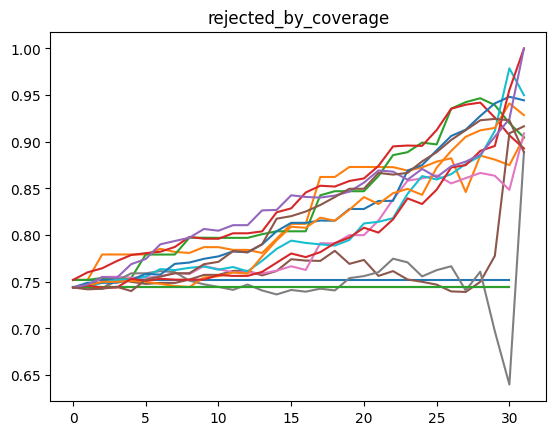

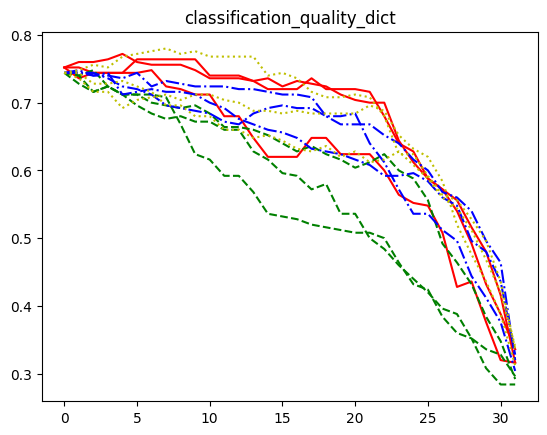

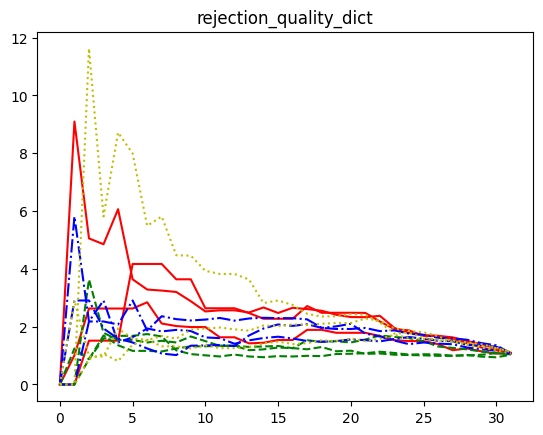

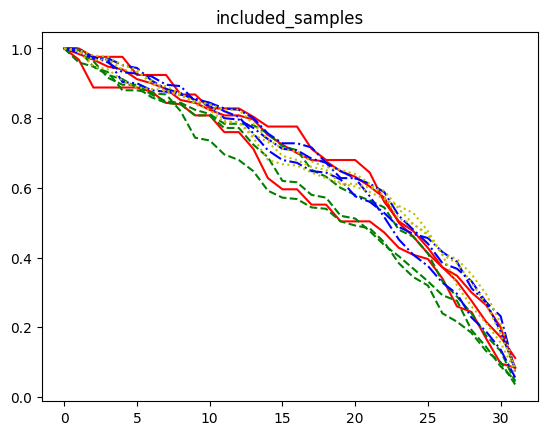

In [19]:
for m in metric_dicts.keys():
    if m=="rejected_by_coverage":
        # place horizontal line at the original bb score
        for k in models.keys():
            plt.plot([0,30],[all_original_scores[k],all_original_scores[k]],label="Original "+k)
        
            plt.plot(metric_dicts[m][k]["PlugInRuleAUC"],label="PlugInRuleAUC")
            plt.plot(metric_dicts[m][k]["PlugInRule"],label="PlugInRule")
            plt.plot(metric_dicts[m][k]["CFDistRejector_l2_mean"],label="CFDistRejector_l2_mean")
    else:
        for k in models.keys():
            model_idx = {k1:i for i,k1 in enumerate(models.keys())}[k]
            ls = ["-","--","-.",":"][model_idx]
            color = ["r","g","b","y"][model_idx]
            plt.plot(metric_dicts[m][k]["PlugInRuleAUC"],label="PlugInRuleAUC",ls=ls,color=color)
            plt.plot(metric_dicts[m][k]["PlugInRule"],label="PlugInRule",ls=ls,color=color)
            plt.plot(metric_dicts[m][k]["CFDistRejector_l2_mean"],label="CFDistRejector_l2_mean",ls=ls,color=color)
    plt.title(m)
    plt.show()


In [20]:
# Create dataframes for visualization
dataframes = create_dataframes(models, metric_dicts, info)

In [21]:
from src.data_processor import fancy_dataset_names


In [22]:
# clean the entries 
if cf_method == "ils":
    if cf_latent:
        cf_method = "ils<latent"
for km in dataframes.keys():
    # remove the name CFDistRejector from the indexes and replace it by the cf_method
    dataframes[km].index = [(f"{cf_method}_{col}" if col not in ["PlugInRule", "PlugInRuleAUC"] else col) for col in dataframes[km].index]
'''for km in dataframes.keys():
    if km not in dataframes.keys():
        all_dataframes[km] = dataframes[km]
    else:
        # drop the raws relatively to the PlugInRule and PlugInRuleAUC
        dataframes[km] = dataframes[km].drop(["PlugInRule", "PlugInRuleAUC"], axis=0)
        all_dataframes[km] = pd.concat([all_dataframes[km], dataframes[km]], axis=0)'''

'for km in dataframes.keys():\n    if km not in dataframes.keys():\n        all_dataframes[km] = dataframes[km]\n    else:\n        # drop the raws relatively to the PlugInRule and PlugInRuleAUC\n        dataframes[km] = dataframes[km].drop(["PlugInRule", "PlugInRuleAUC"], axis=0)\n        all_dataframes[km] = pd.concat([all_dataframes[km], dataframes[km]], axis=0)'

Visualizing results:   0%|          | 0/4 [00:00<?, ?it/s]

Dropping duplicates
ils<latent_CFDistRejector_cosine_min ILS$_{latent}$ - cosine$^{\gamma}_{min}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$^{\gamma}_{max}$
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$^{\gamma}_{mean}$
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$^{\gamma}_{max}$
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$^{\gamma}_{mean}$
ils<latent_CFDistRejector_cosine_min ILS$_{latent}$ - cosine$_{min}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$_{max}$
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$_{mean}$
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$_{mean}$
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$_{max}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$^{\gamma}_{min}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$_{min}$
ils<latent_CFTreeRejector_cosine_mean ILS$_{latent}$ (Tree) - cosine$_{mean}$ (D)
ils<latent_CFTreeRejector_l2_mean ILS$_{latent}$ (Tree) 

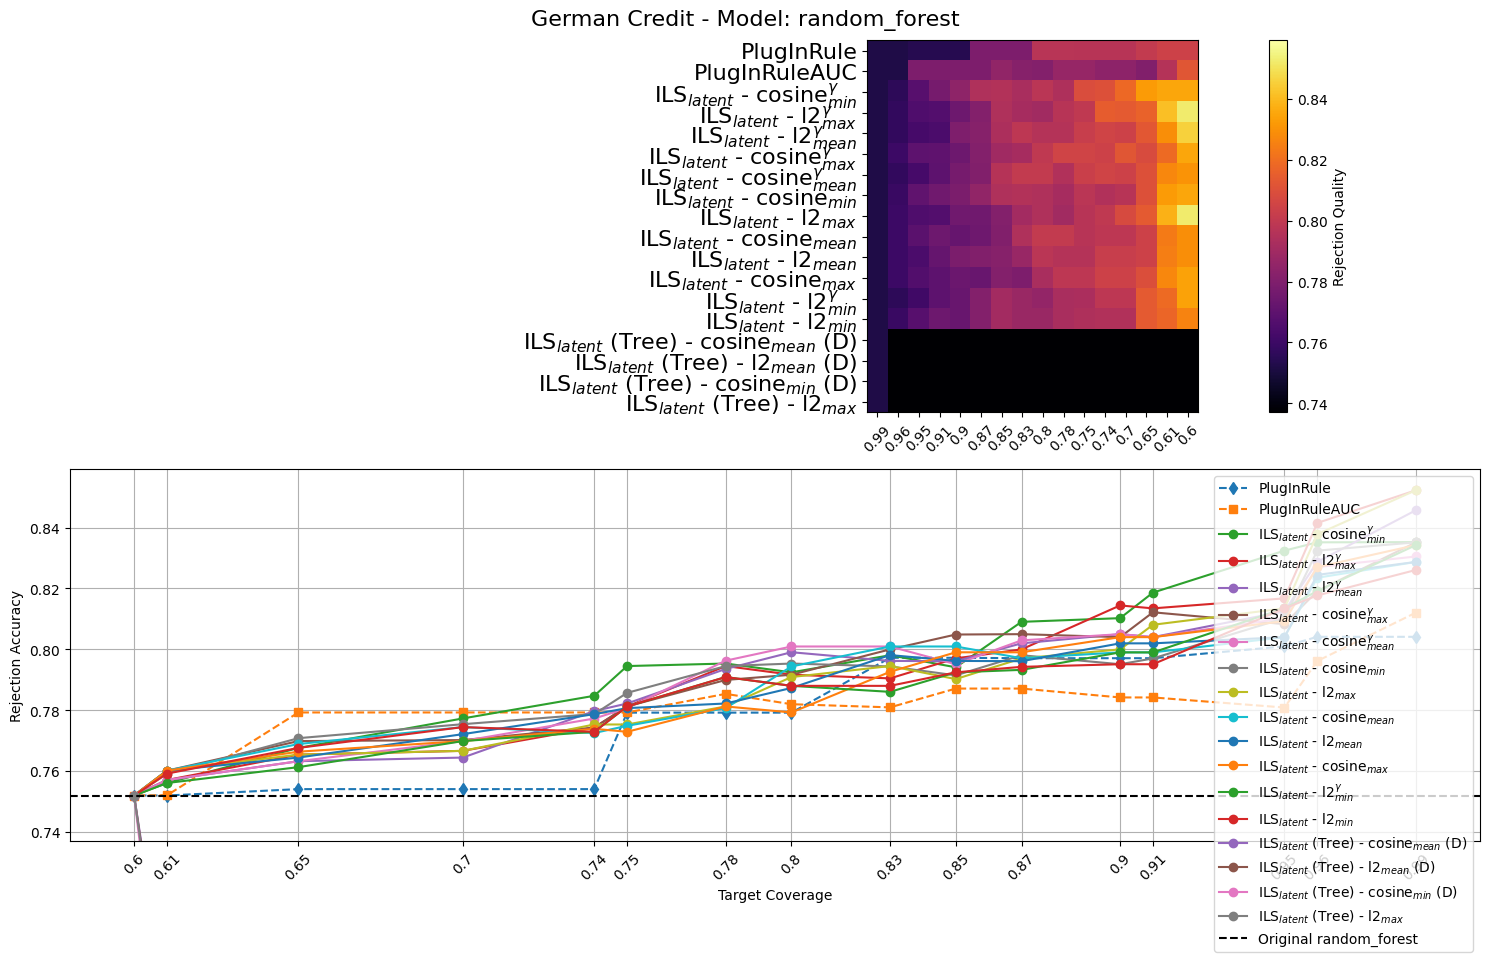

Visualizing results:  25%|██▌       | 1/4 [00:00<00:02,  1.19it/s]

Dropping duplicates
ils<latent_CFTreeRejector_l2_max ILS$_{latent}$ (Tree) - l2$_{max}$ (D)
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$_{mean}$
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$^{\gamma}_{mean}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$_{min}$
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$^{\gamma}_{max}$
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$^{\gamma}_{mean}$
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$_{mean}$
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$_{max}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$^{\gamma}_{min}$
ils<latent_CFTreeRejector_cosine_max ILS$_{latent}$ (Tree) - cosine$_{max}$
ils<latent_CFTreeRejector_cosine_max ILS$_{latent}$ (Tree) - cosine$^{\gamma}_{max}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$^{\gamma}_{max}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$_{max}$
ils<latent_CFDistRejector_cosine_min ILS$_{latent}$ 

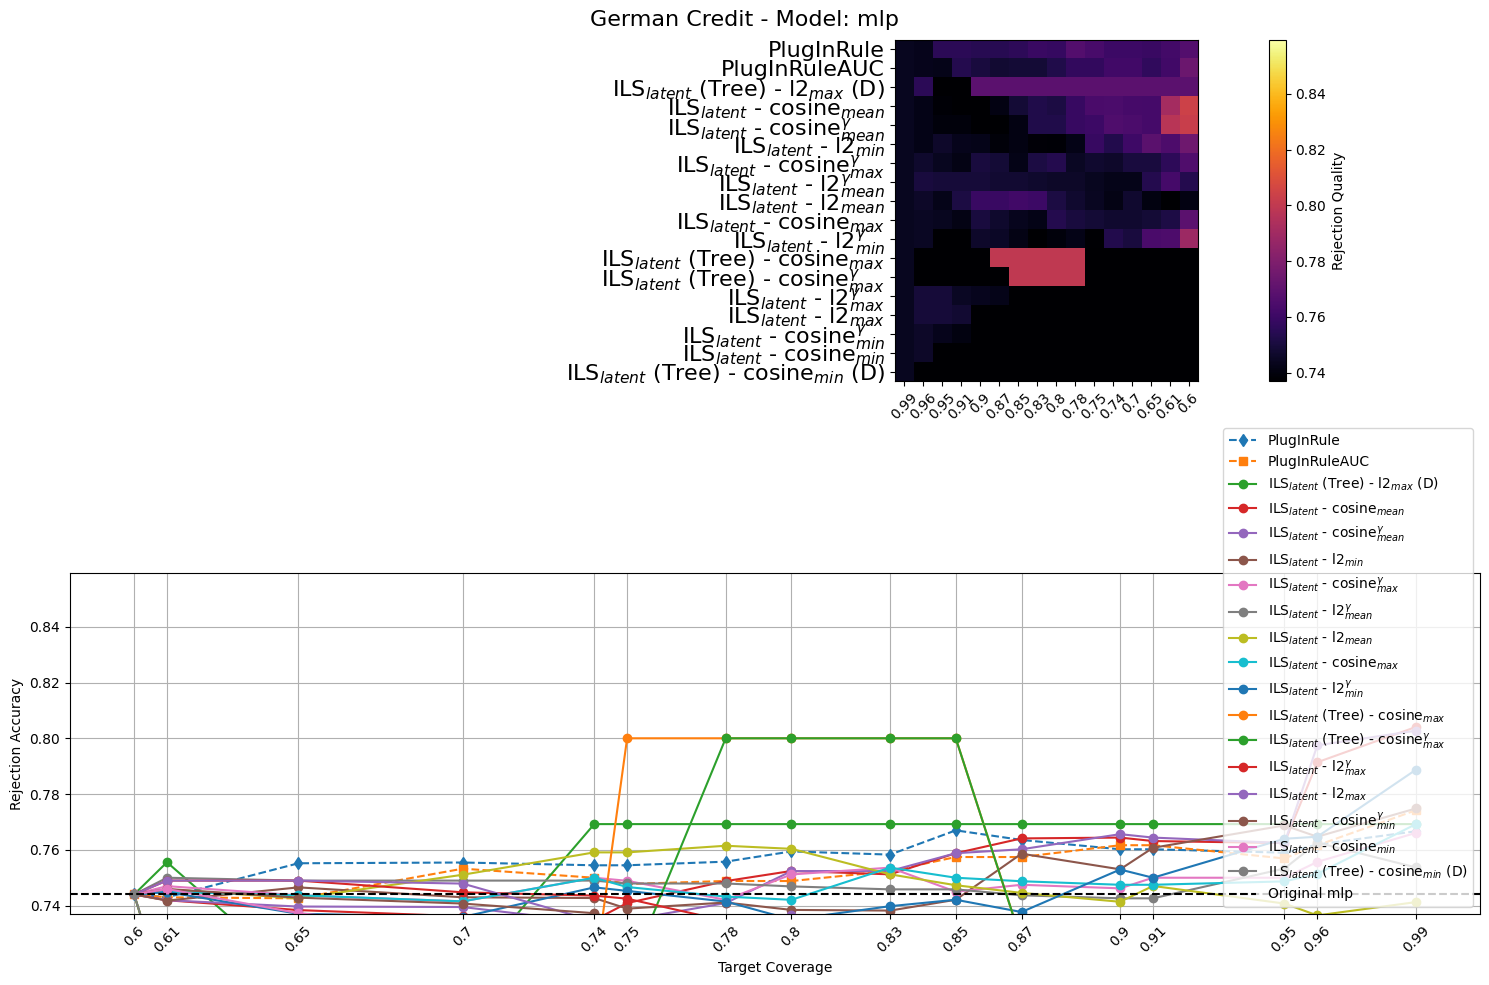

Visualizing results:  50%|█████     | 2/4 [00:01<00:01,  1.21it/s]

Dropping duplicates
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$^{\gamma}_{mean}$
ils<latent_CFDistRejector_cosine_min ILS$_{latent}$ - cosine$^{\gamma}_{min}$
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$^{\gamma}_{max}$
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$^{\gamma}_{mean}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$^{\gamma}_{max}$
ils<latent_CFDistRejector_cosine_min ILS$_{latent}$ - cosine$_{min}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$_{min}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$_{max}$
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$_{max}$
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$_{mean}$
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$_{mean}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$^{\gamma}_{min}$
ils<latent_CFTreeRejector_l2_min ILS$_{latent}$ (Tree) - l2$^{\gamma}_{min}$
ils<latent_CFTreeRejector_cosine_min ILS$_{latent}$ (Tree) - 

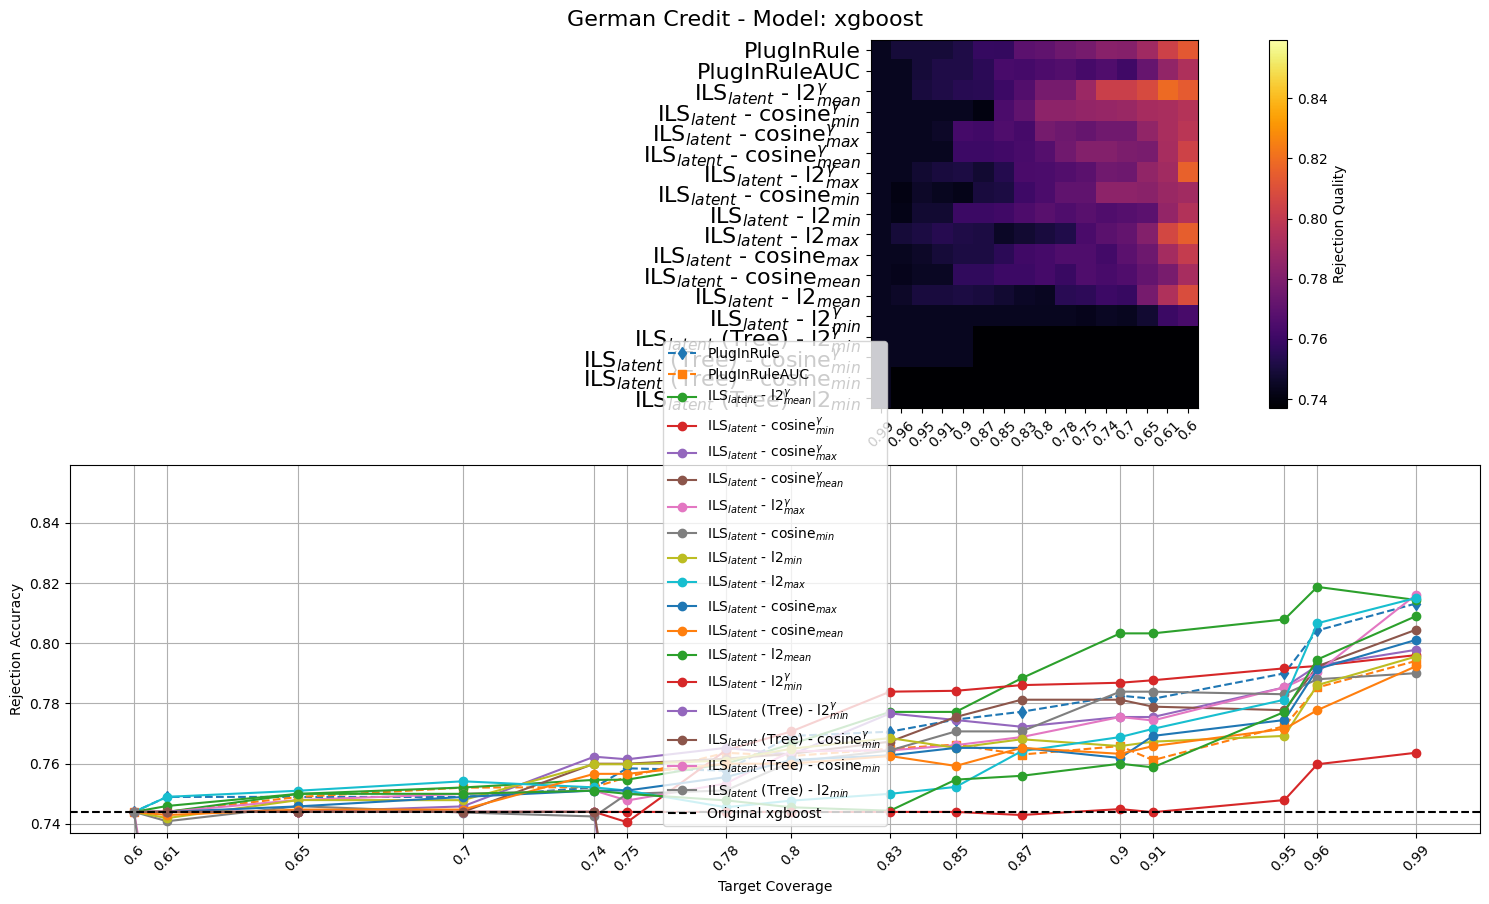

Visualizing results:  75%|███████▌  | 3/4 [00:02<00:00,  1.15it/s]

Dropping duplicates
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$^{\gamma}_{max}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$^{\gamma}_{min}$
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$^{\gamma}_{mean}$
ils<latent_CFDistRejector_cosine_min ILS$_{latent}$ - cosine$^{\gamma}_{min}$
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$^{\gamma}_{mean}$
ils<latent_CFDistRejector_l2_min ILS$_{latent}$ - l2$_{min}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$^{\gamma}_{max}$
ils<latent_CFDistRejector_cosine_min ILS$_{latent}$ - cosine$_{min}$
ils<latent_CFDistRejector_l2_mean ILS$_{latent}$ - l2$_{mean}$
ils<latent_CFDistRejector_l2_max ILS$_{latent}$ - l2$_{max}$
ils<latent_CFDistRejector_cosine_mean ILS$_{latent}$ - cosine$_{mean}$
ils<latent_CFDistRejector_cosine_max ILS$_{latent}$ - cosine$_{max}$
ils<latent_CFTreeRejector_l2_mean ILS$_{latent}$ (Tree) - l2$_{mean}$
ils<latent_CFTreeRejector_l2_mean ILS$_{latent}$ (Tree) - l2$^{\gamm

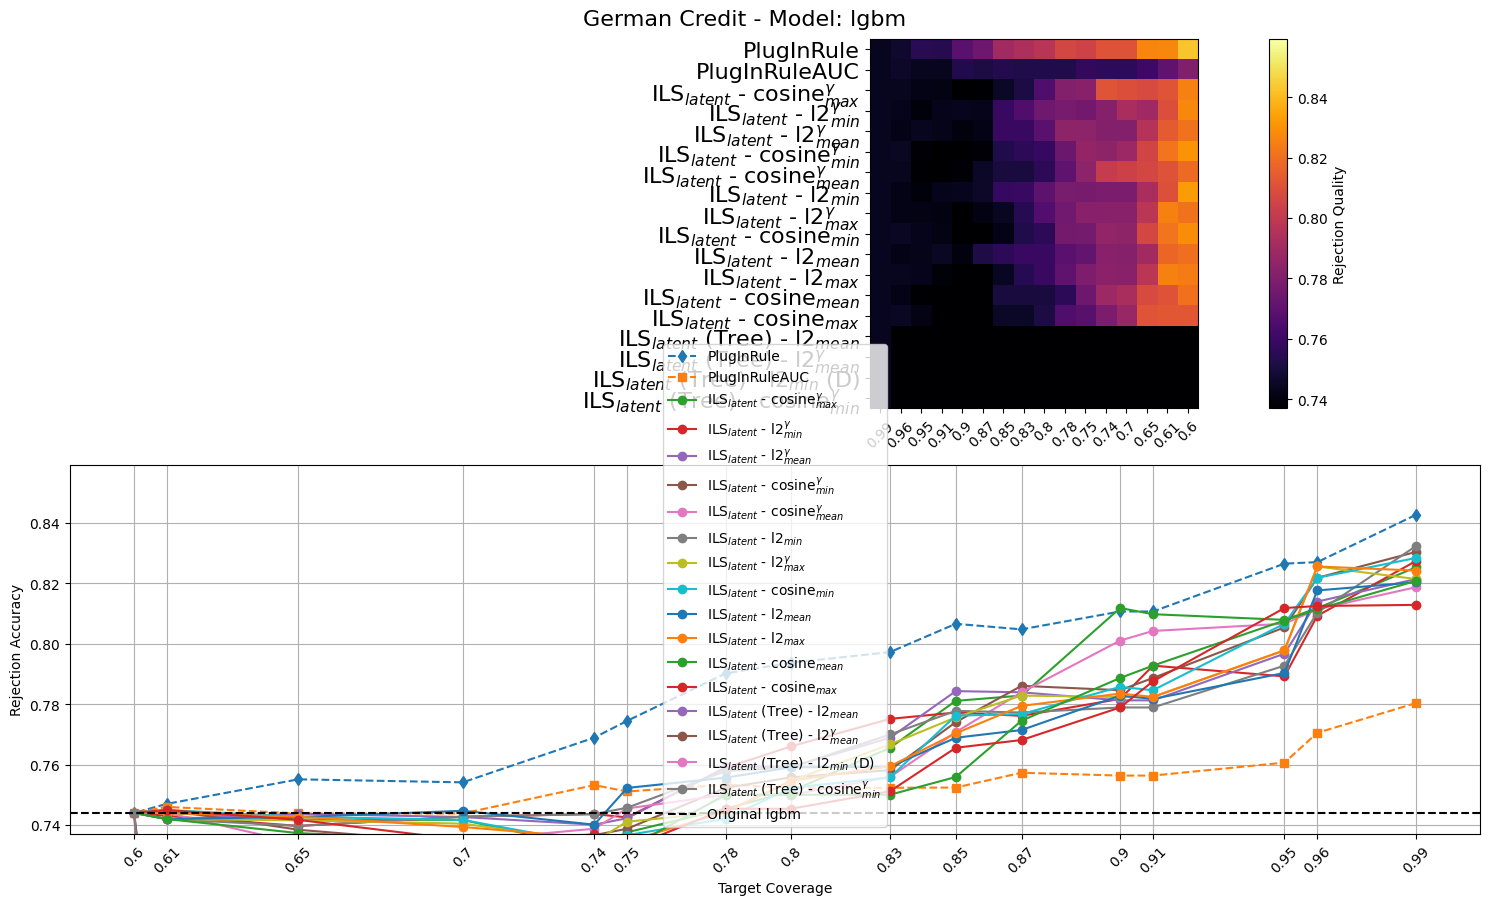

Visualizing results: 100%|██████████| 4/4 [00:03<00:00,  1.17it/s]


In [24]:
visualize_results(models=models,
                  dataframes=dataframes,
                  info=info,
                  plot_dir="..",
                  name_dataset=fancy_dataset_names[dt_name],
                  show=True,
                  top_k=18)

In [ ]:
dataframes["mlp"].head()

,0.99,0.96,0.95,0.91,0.90,0.87,0.85,0.83,0.80,0.78,...,0.39,0.35,0.31,0.26,0.22,0.17,0.13,0.09,0.04,0.00
PlugInRule,0.744,0.742972,0.755187,0.755459,0.754464,0.754464,0.755760,0.759434,0.758294,0.766990,...,0.838235,0.858333,0.860870,0.864078,0.855422,0.861111,0.866667,0.863636,0.848485,0.909091
PlugInRuleAUC,0.744,0.742972,0.742616,0.753247,0.750000,0.747748,0.748837,0.748815,0.752381,0.757426,...,0.761468,0.752475,0.750000,0.746988,0.739726,0.739130,0.750000,0.777778,0.909091,0.916667
CFDistRejector_cosine_min,0.744,0.745968,0.737288,0.731602,0.717073,0.722772,0.718919,0.711111,0.706215,0.710059,...,0.666667,0.666667,0.684932,0.727273,0.782609,0.810811,0.838710,0.826087,0.800000,0.857143
CFDistRejector_cosine_min_gamma,0.744,0.745968,0.742857,0.740741,0.737288,0.733906,0.719626,0.721154,0.722772,0.717277,...,0.690722,0.658824,0.675676,0.741379,0.833333,0.791667,0.769231,0.777778,0.857143,0.857143
CFDistRejector_cosine_max,0.744,0.744939,0.743697,0.741525,0.750000,0.746667,0.743243,0.742081,0.753623,0.750000,...,0.795082,0.780702,0.783019,0.774194,0.768293,0.750000,0.730769,0.750000,0.769231,0.666667


In [ ]:
all_dataframes = {}
    # Load distance statistics for the cf_methods 
    for cf_method in ["ils","ils_latent","lore"]:#,"dice"]:
        if cf_method == "ils_latent":
            args.latent = True
            cf_method = "ils"
        else:
            args.latent = False
        all_stats, all_stats_test = load_distance_stats(cf_method, args.dataset, args.latent)
        # Check if distances are computed
        for k in models.keys():
            print(k, "computed?", check_res(stats_dict=all_stats, k=k))
            print("\t", "test?", check_res(stats_dict=all_stats_test, k=k))
        
        # Convert lists to arrays
        all_stats = convert_lists_to_arrays(models, all_stats)
        all_stats_test = convert_lists_to_arrays(models, all_stats_test)
        # retain only the L2 and the cosine distance
        #all_stats = {k: {"distances": {m: all_stats[k]["distances"][m] for m in ["l2", "cosine"]}} for k in all_stats.keys()}
        #all_stats_test = {k: {"distances": {m: all_stats_test[k]["distances"][m] for m in ["l2", "cosine"]}} for k in all_stats_test.keys()}

        # Initialize selective classifiers
        rejectors, metric_dicts, info = initialize_rejectors(models, splits)
    
        # Calibrate basic rejectors
        rejectors = calibrate_basic_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)
    
        rejectors = calibrate_distance_rejectors(models, rejectors, splits, all_stats, all_stats_test, info)
        

        # Evaluate all rejectors
        metric_dicts = evaluate_rejectors(models, rejectors, splits, metric_dicts, info)
    
        # Create dataframes for visualization
        dataframes = create_dataframes(models, metric_dicts, info)
        print(type(dataframes["mlp"]), dataframes["mlp"].columns)
        # dataframes is a dict of dataframes, the key is the model, the value the dataframe
        if cf_method == "ils":
            if args.latent:
                cf_method = "ils<latent"
        for km in dataframes.keys():
            # remove the name CFDistRejector from the indexes and replace it by the cf_method
            dataframes[km].index = [(f"{cf_method}_{col}" if col not in ["PlugInRule", "PlugInRuleAUC"] else col) for col in dataframes[km].index]
        for km in dataframes.keys():
            if km not in all_dataframes.keys():
                all_dataframes[km] = dataframes[km]
            else:
                # drop the raws relatively to the PlugInRule and PlugInRuleAUC
                dataframes[km] = dataframes[km].drop(["PlugInRule", "PlugInRuleAUC"], axis=0)
                all_dataframes[km] = pd.concat([all_dataframes[km], dataframes[km]], axis=0)

In [ ]:
# This function calculates the selective metrics for a given model and selective technique
# model_key: the key of the model in the models dictionary
# selected_data: the data selected by the selective technique
# classifier_type: the type of the classifier
# plug_in_ruler: the plug-in ruler of the model
# splits: the splits of the data
# coverage_index: the index of the coverage
# n: the number of samples
# metric_dicts: the dictionary of the metrics

Visualizing results:   0%|          | 0/4 [00:00<?, ?it/s]

Dropping duplicates


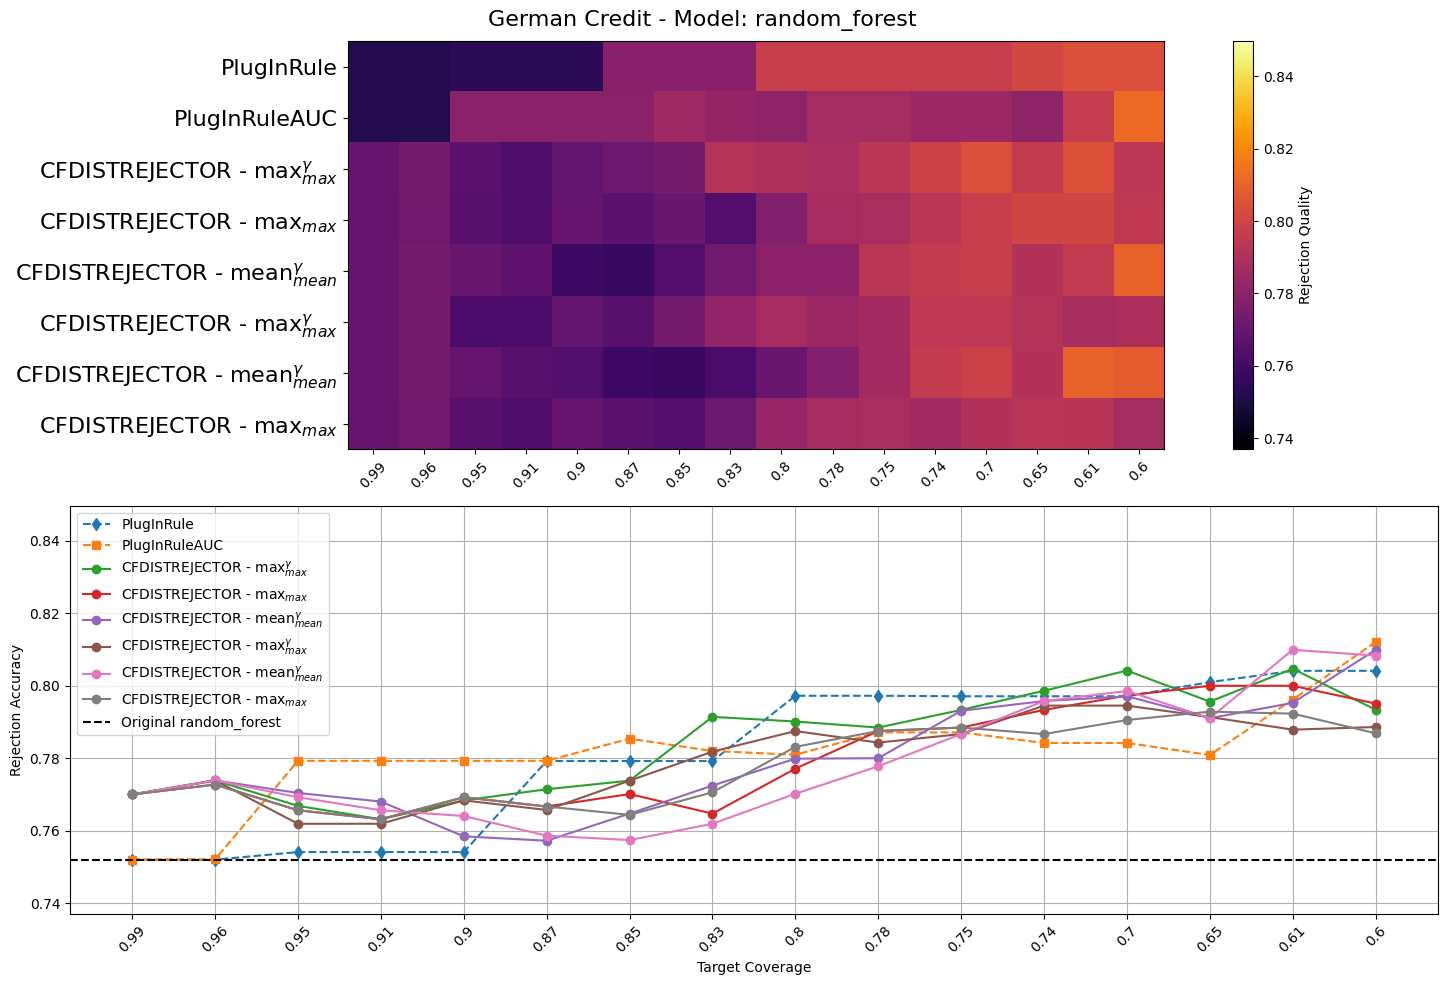

Visualizing results:  25%|██▌       | 1/4 [00:00<00:01,  1.60it/s]

Dropping duplicates


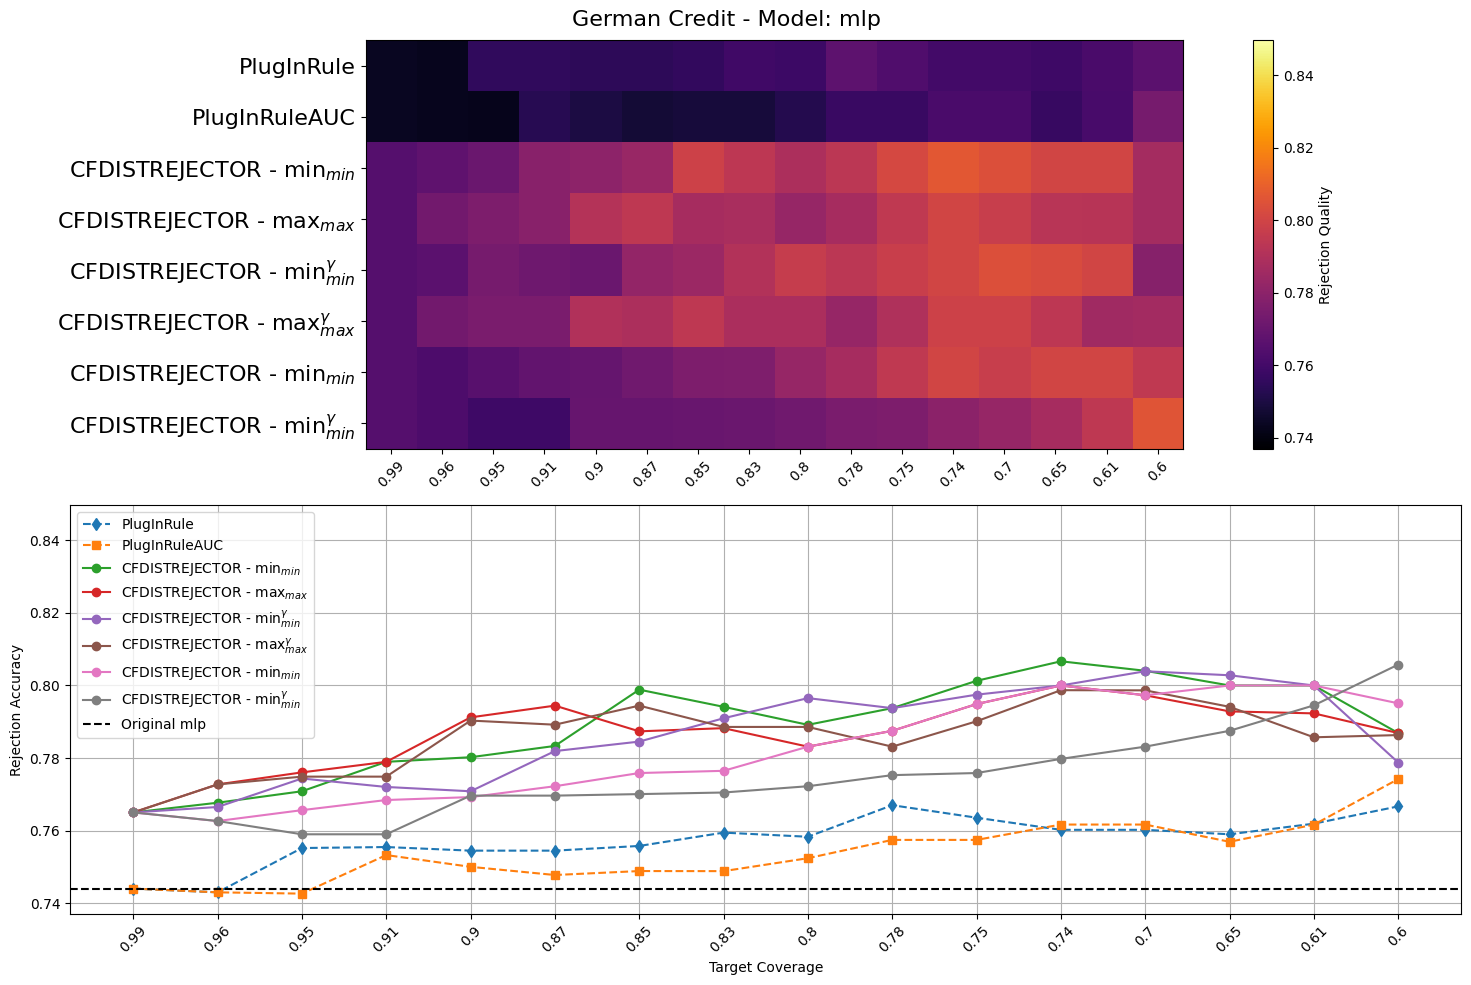

Visualizing results:  50%|█████     | 2/4 [00:01<00:01,  1.87it/s]

Dropping duplicates


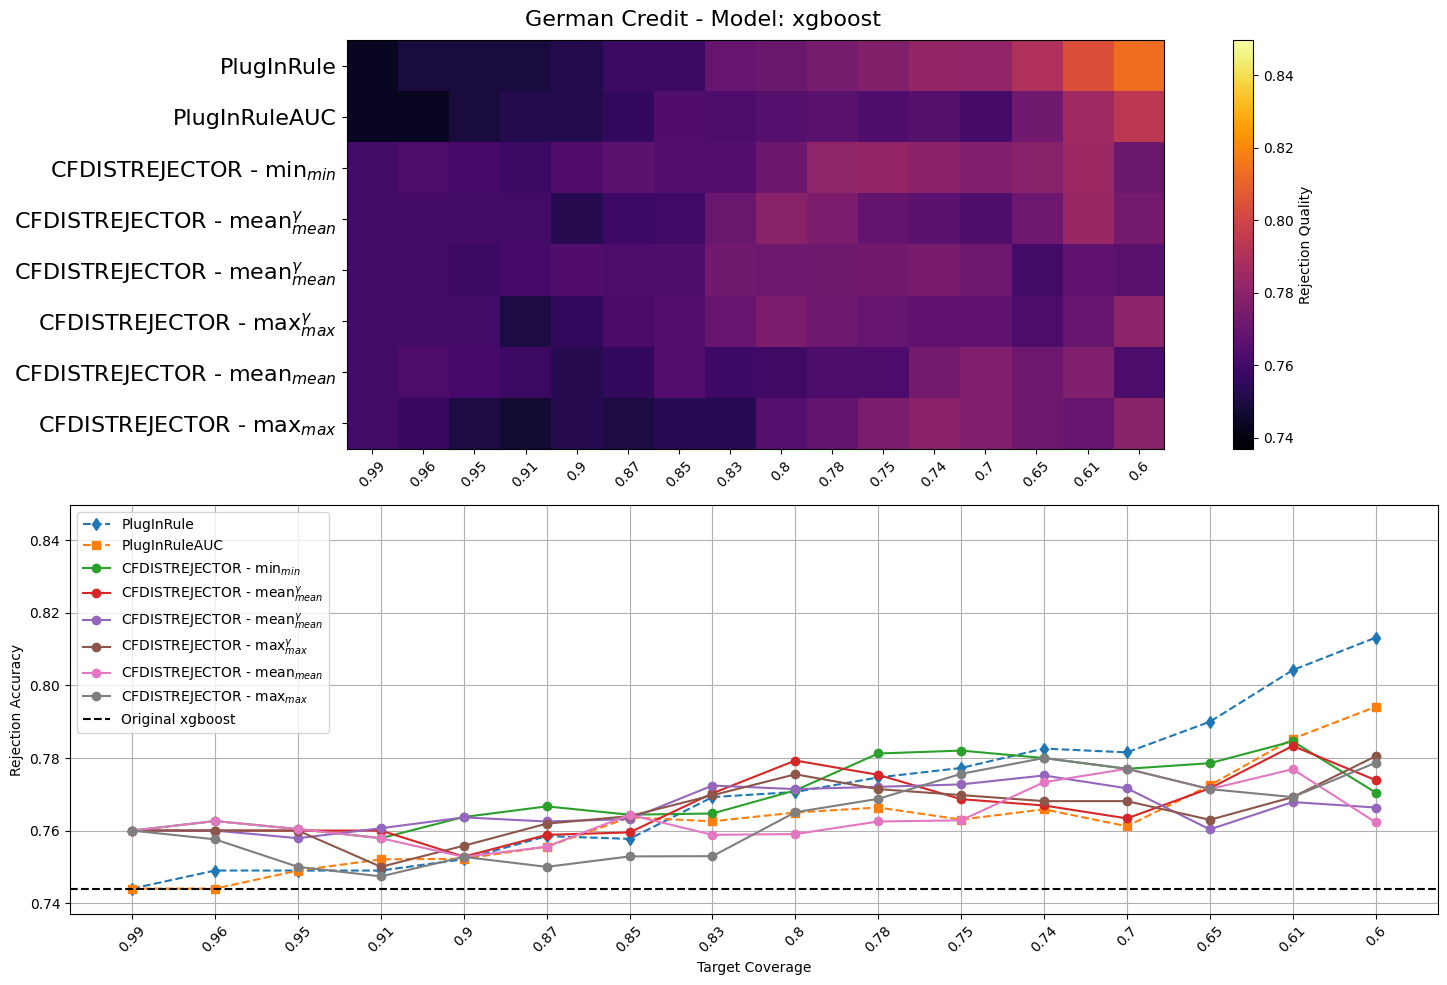

Visualizing results:  75%|███████▌  | 3/4 [00:01<00:00,  1.95it/s]

Dropping duplicates


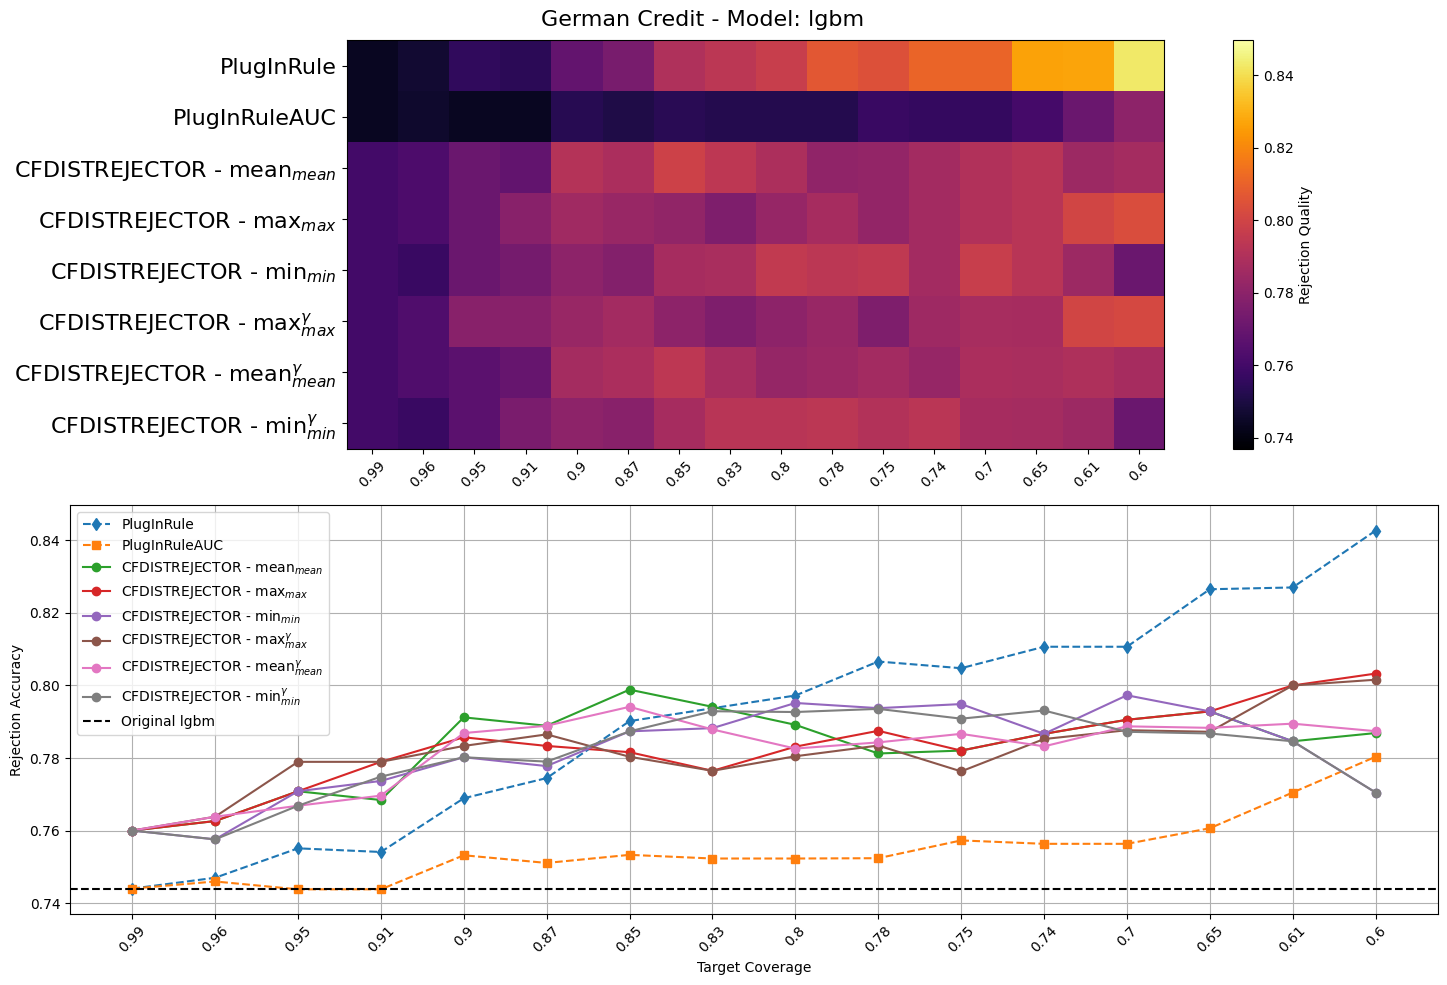

Visualizing results: 100%|██████████| 4/4 [00:02<00:00,  1.93it/s]


In [ ]:
## here I can have the results for the selective classifiers for the dataset dt_name, and the method cf_method
# just for the sake of the example, let's print the results for the first model in a fancy way:
# we plot the best selective classifier for each target coverage
k = list(models.keys())[0]
# make a big figure to plot the results
fig,ax = plt.subplots(1,4,figsize=(20,5))
ax = ax.flatten()
# for each model we plot the results
dataframes = {}
selective_metric = "rejected_by_coverage"

for k in models.keys():
    
    metric_dicts[selective_metric][k]
    df = pd.DataFrame()
    # place each k,v in a dataframe
    for chey,val in metric_dicts[selective_metric][k].items():
        df[chey] = val
    # invert the rows and columns
    df = df.T
    # rename the columns as the target coverages
    df.columns = target_coverages
    dataframes[k] = df

vmedian = min(all_original_scores.values())
vmax = 1
vmin = min([df.values.min() for df in dataframes.values()]+[vmedian])
cmap_base = sns.color_palette("BrBG_r", as_cmap=True)
# now change the diverging map cmap_base so that the mid point (white) corresponds to the median value
#cmap = shiftedColorMap(cmap_base, midpoint=vmedian,vmin=vmin, vmax=vmax)

# Calculate the midpoint in the range from vmin to vmax that corresponds to vmedian
midpoint = (vmedian - vmin) / (vmax - vmin)

# Use the BrBG_r colormap as the base
cmap_base = sns.color_palette("BrBG_r", as_cmap=True)

# Create a new colormap with the shifted midpoint
custom_cmap = shiftedColorMap(cmap_base, midpoint=midpoint)
#cmap = sns.diverging_palette(220, 20, as_cmap=True)



In [ ]:
# dataframes[k]


In [ ]:
markers = ["o","d","s","v","^","p"]*100
colors = ["blue","red","green","purple"]*100
markers = markers*100

In [ ]:
from typing import Any, Dict
from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
from OLD_src.MyLoreSA.metrics import nonrejected_accuracy, classification_quality, rejection_quality, rejection_classification_report


In [ ]:
#iterate over the models
rejected_by_coverage = dataframes["rejected_by_coverage"]
included_samples = dataframes["included_samples"]
target_coverages_n = len(rejected_by_coverage[list(models.keys())[0]].keys())

fig, ax = plt.subplots(1,#len(models.keys())//2,
                       len(models.keys()),
                       figsize=(24,5))
ax = ax.flatten()
for jj,k in enumerate(models.keys()):
    axx2 = ax[jj].twinx()
    for selective_k,marker,color in zip(rejected_by_coverage[k].keys(),
                                        markers,
                                        colors):
        rejected_acc = rejected_by_coverage[k][selective_k]
        ax[jj].plot(np.arange(len(rejected_acc))/len(rejected_acc), rejected_acc, 
                    label=selective_k.replace("_gamma"," $_\gamma$"),
                    marker=marker,
                    color=color)

        ax[jj].set_title(k,fontsize=15)
        ax[jj].set_xlabel('Rejection rate', fontsize=15)
        # set the xticks to be 1%, 25 % , 50 %, 75 % and 99
        ax[jj].set_xticks([0.01,0.25,0.5,0.75,0.99])
        # add the percentage sign
        ax[jj].set_xticklabels(['1%','25%','50%','75%','99%'], fontsize=13)
        ax[jj].set_ylabel('Non-rejected accuracy', fontsize=15)
        ax[jj].grid()
        # plot the 0% rejection accuracy
        low_y_lim = -0.05
        low_y_lim = min(all_original_scores.values())
        ax[jj].set_ylim(low_y_lim-0.025,1.025)
        # get the ticks for the y axis of ax, and be sure to not exceed 1.0 as tick
        ax[jj].set_yticks(np.linspace(low_y_lim,1.0,6).round(2))
        # set the font of the y ticks
        ax[jj].yaxis.set_tick_params(labelsize=13)
        # get the twin axis
        
        # plot the number of included samples in the classification
        included_samp = included_samples[k][selective_k]
        axx2.plot(np.arange(target_coverages_n)/target_coverages_n, included_samp, 
                    label="% samples",
                    
                    color=color,
                    linestyle="-",alpha=0.3)

    axx2.set_ylabel("Included samples",fontsize=15,rotation=270)
    # set the yticks to be 0, 25 % , 50 %, 75 % and 100 %
    axx2.set_yticks([0,0.25,0.5,0.75,1])
    # add the percentage sign
        # to be ure add the "target" rejection rate as a diagonal line
    axx2.set_yticklabels(['0%','25%','50%','75%','100%'], fontsize=13)
    # place grid on the y axis
    ax[jj].grid()
    axx2.set_ylim(-0.025,1.025)
    #ax[jj].set_xlim(-0.05,.5)
    ax[jj].axhline(all_original_scores[k],linestyle="--",
        color="black",label=k)
    axx2.plot([0,1],[1,0],color="black",linestyle="-.",alpha=0.3)
    #ax[jj].legend(loc="lower center")
    # plot the y grid
    ax[jj].grid(axis='y')
plt.suptitle("Non-rejected accuracy - " + name_dataset +" "+ cf_method + ("latent" if cf_latent else ""),fontsize=20)
plt.tight_layout()
for k in models.keys():
    # roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    # print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(4)
    print(f"Model {k} Accuracy: {acc}")
plt.show()

KeyError: 'rejected_by_coverage'

## Add Statistical tests to the Selective classifiers


# TODO add other metrics